In [15]:
import pandas as pd
import numpy as np
import pyodbc
import warnings
warnings.filterwarnings('ignore')

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost,1433;"
    "DATABASE=ProductieSolaraDB_V2;"
    "UID=sa;"
    "PWD=Spidy400!"
)
conn = pyodbc.connect(conn_str)

df_train = pd.read_sql("SELECT Time_Stamp FROM Train", conn)

df_loggers = pd.read_sql("SELECT Time_Stamp, Loggers_0_Energy_Yield_Daily FROM LoggersTRENDS", conn)

df_meteo = pd.read_sql("SELECT Time_Stamp, Meteo_SolarIrradiation1, Meteo_SolarIrradiation2 FROM MeteoTRENDS", conn)

df_alarms = pd.read_sql("SELECT Al_Start_Time, Al_Message FROM ALARMHISTORY", conn)

df_train['Time_Stamp'] = pd.to_datetime(df_train['Time_Stamp'])
df_loggers['Time_Stamp'] = pd.to_datetime(df_loggers['Time_Stamp'])
df_meteo['Time_Stamp'] = pd.to_datetime(df_meteo['Time_Stamp'])
df_alarms['Al_Start_Time'] = pd.to_datetime(df_alarms['Al_Start_Time'])

In [ ]:
data_start_oficiala = df_train['Time_Stamp'].min()
df_loggers = df_loggers[df_loggers['Time_Stamp'] >= data_start_oficiala]

df_loggers_daily = df_loggers.set_index('Time_Stamp').resample('D').agg({
    'Loggers_0_Energy_Yield_Daily': 'max'
}).reset_index()

df_meteo_daily = df_meteo.set_index('Time_Stamp').resample('D').agg({
    'Meteo_SolarIrradiation1': 'sum',
    'Meteo_SolarIrradiation2': 'sum'
}).reset_index()

zile_cu_alarme = df_alarms['Al_Start_Time'].dt.floor('D').unique()

df_daily = pd.merge(df_loggers_daily, df_meteo_daily, on='Time_Stamp', how='inner')
df_daily.rename(columns={'Time_Stamp': 'Date'}, inplace=True)

In [ ]:
df_daily = pd.merge(df_loggers_daily, df_meteo_daily, on='Time_Stamp', how='inner')
df_daily.rename(columns={'Time_Stamp': 'Date'}, inplace=True)
df_daily = df_daily[df_daily['Date'].dt.dayofweek < 5]

scaling_factor = 28 / 3
df_daily['Total_Park_Daily_Yield'] = df_daily['Loggers_0_Energy_Yield_Daily'] * scaling_factor

df_final = df_daily[['Date', 'Meteo_SolarIrradiation1', 'Meteo_SolarIrradiation2', 'Total_Park_Daily_Yield']].copy()

df_final.reset_index(drop=True, inplace=True)

display(df_final.head())
print(f"Dimensiunea setului de antrenare: {df_final.shape[0]} zile lucrătoare perfect curate.")

,Date,Meteo_SolarIrradiation1,Meteo_SolarIrradiation2,Total_Park_Daily_Yield
0,2026-05-18,855375.0,868304.0,63160.533333
1,2026-05-19,2974945.0,2996684.0,180418.000000
2,2026-05-20,3602664.0,3617848.0,198329.600000
3,2026-05-21,2921950.0,2969071.0,198329.600000
4,2026-05-22,3630213.0,3653717.0,152500.133333


Dimensiunea setului de antrenare: 26 zile lucrătoare perfect curate.


In [18]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

features = ['Meteo_SolarIrradiation1', 'Meteo_SolarIrradiation2']
target = ['Total_Park_Daily_Yield']

data_features = df_final[features].values
data_target = df_final[target].values

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaled_X = scaler_X.fit_transform(data_features)
scaled_y = scaler_y.fit_transform(data_target)

def create_sequences(X, y, time_steps=5):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 5
X_seq, y_seq = create_sequences(scaled_X, scaled_y, TIME_STEPS)

split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print(f"Forma X_train: {X_train.shape} -> (Samples, Time Steps, Features)")

Forma X_train: (16, 5, 2) -> (Samples, Time Steps, Features)


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def build_and_train_model(model_type, X_tr, y_tr, X_te, y_te):
    model = Sequential()
    
    if model_type == 'MLP':
        model.add(Flatten(input_shape=(X_tr.shape[1], X_tr.shape[2])))
        model.add(Dense(64, activation='relu'))
        model.add(Dropout(0.2))
        model.add(Dense(32, activation='relu'))
        
    elif model_type == 'LSTM':
        model.add(LSTM(64, input_shape=(X_tr.shape[1], X_tr.shape[2])))
        model.add(Dropout(0.2))
        model.add(Dense(32, activation='relu'))
        
    elif model_type == 'GRU':
        model.add(GRU(64, input_shape=(X_tr.shape[1], X_tr.shape[2])))
        model.add(Dropout(0.2))
        model.add(Dense(32, activation='relu'))

    model.add(Dense(1))
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    print(f"\n--- Antrenare model: {model_type} ---")
    history = model.fit(
        X_tr, y_tr,
        epochs=100,
        batch_size=16,
        validation_data=(X_te, y_te),
        callbacks=[early_stop],
        verbose=0
    )
    
    test_loss, test_mae = model.evaluate(X_te, y_te, verbose=0)
    
    y_pred_scaled = model.predict(X_te, verbose=0)
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
    y_test_real = scaler_y.inverse_transform(y_te)
    
    return history, test_mae, y_test_real, y_pred_real

models_to_test = ['MLP', 'LSTM', 'GRU']
results = {}

for m in models_to_test:
    hist, mae, y_true, y_pred = build_and_train_model(m, X_train, y_train, X_test, y_test)
    results[m] = {
        'mae_scaled': mae,
        'y_true': y_true,
        'y_pred': y_pred
    }

I0000 00:00:1784288811.443163    4638 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784288811.450974    4638 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784288812.051497    4638 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784288815.457081    4638 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0


--- Antrenare model: MLP ---

--- Antrenare model: LSTM ---

--- Antrenare model: GRU ---


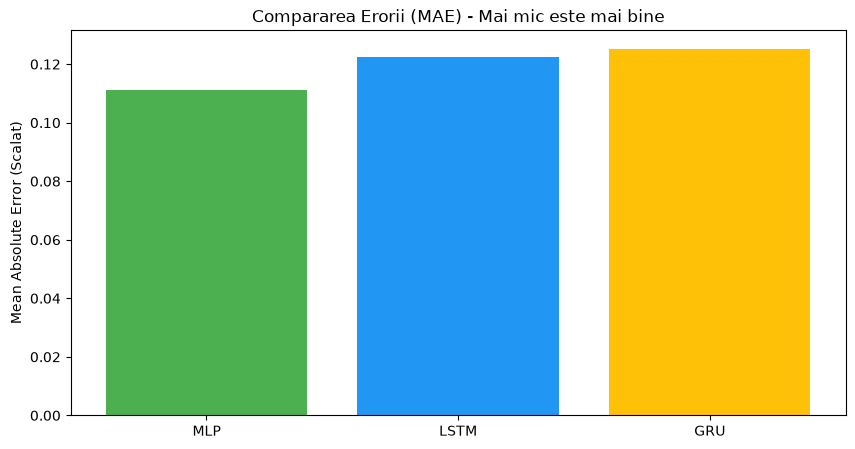

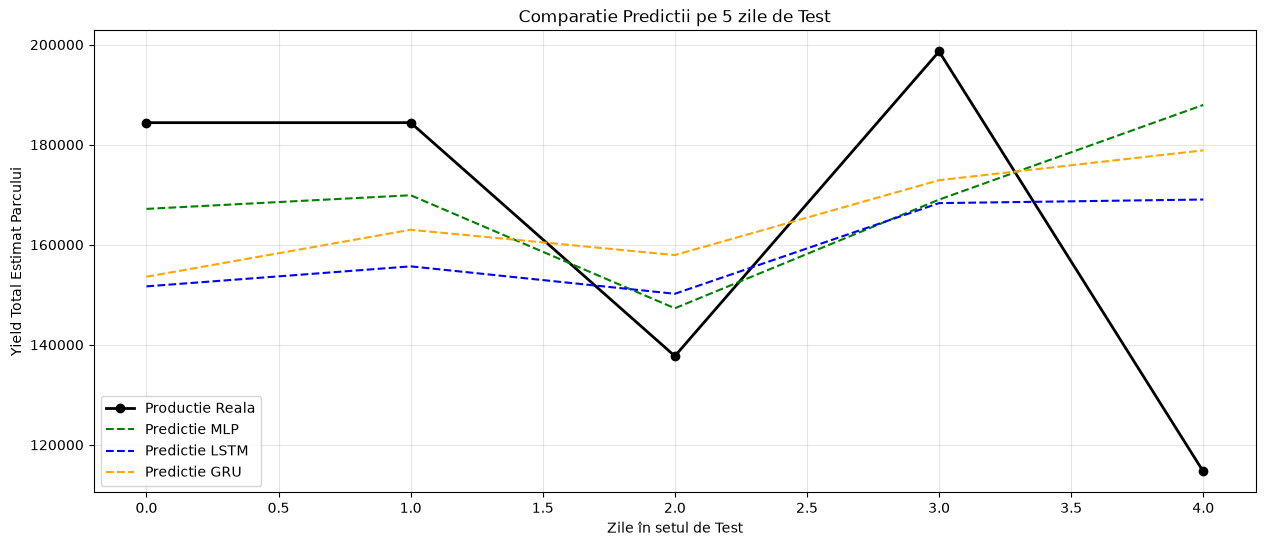

In [20]:
import matplotlib.pyplot as plt

num_samples = min(30, len(results['MLP']['y_true']))
timp_zile = range(num_samples)

plt.figure(figsize=(10, 5))
maes = [results[m]['mae_scaled'] for m in models_to_test]
plt.bar(models_to_test, maes, color=['#4CAF50', '#2196F3', '#FFC107'])
plt.title('Compararea Erorii (MAE) - Mai mic este mai bine')
plt.ylabel('Mean Absolute Error (Scalat)')
plt.show()

plt.figure(figsize=(15, 6))

plt.plot(timp_zile, results['MLP']['y_true'][:num_samples], label='Productie Reala', color='black', linewidth=2, marker='o')

colors = {'MLP': 'green', 'LSTM': 'blue', 'GRU': 'orange'}
for m in models_to_test:
    y_pred_flat = results[m]['y_pred'][:num_samples].flatten()
    plt.plot(timp_zile, y_pred_flat, label=f'Predictie {m}', color=colors[m], linestyle='dashed')

plt.title(f'Comparatie Predictii pe {num_samples} zile de Test')
plt.xlabel('Zile în setul de Test')
plt.ylabel('Yield Total Estimat Parcului')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Antrenăm modelul autoregresiv pentru forecast...


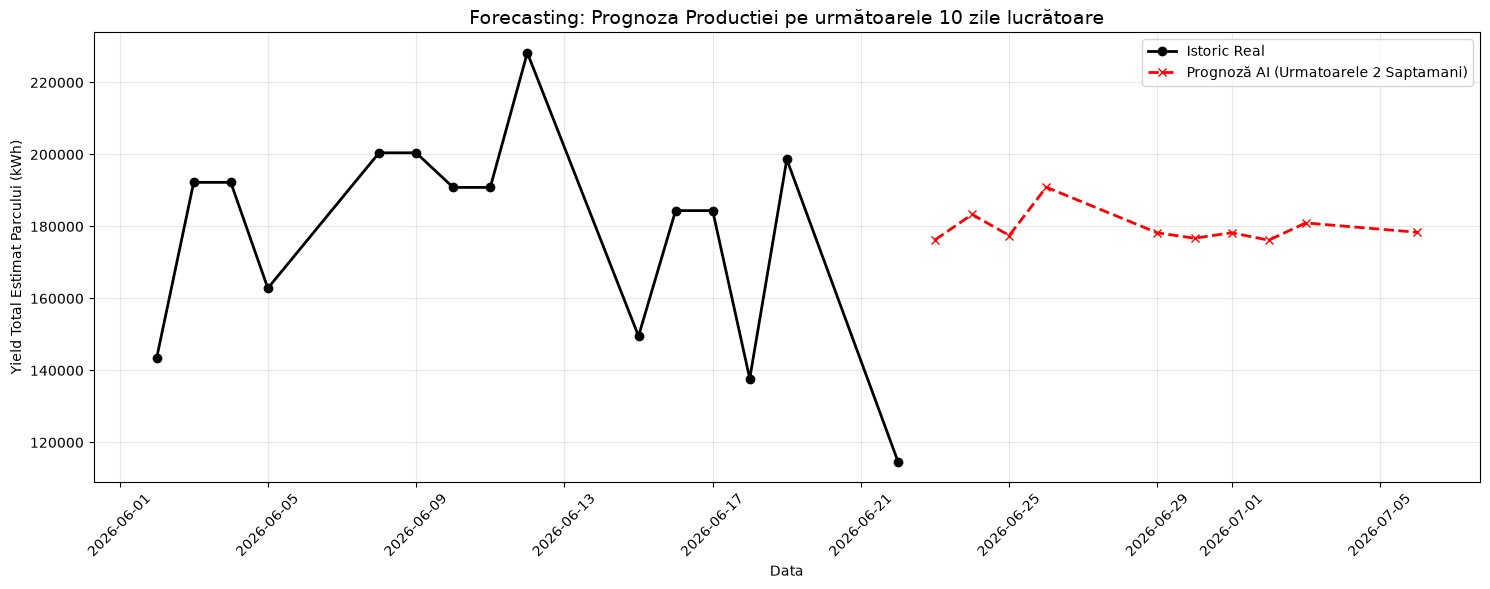


Valorile estimate pentru următoarele 2 saptamani:


,Data_Viitoare,Productie_Estimata_kWh
0,2026-06-23,176277.921875
1,2026-06-24,183349.140625
2,2026-06-25,177484.171875
3,2026-06-26,190904.156250
4,2026-06-29,178219.562500
5,2026-06-30,176733.671875
6,2026-07-01,178250.109375
7,2026-07-02,176183.609375
8,2026-07-03,180979.703125
9,2026-07-06,178384.500000


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

target_data = df_final[['Total_Park_Daily_Yield']].values
scaler_future = MinMaxScaler()
scaled_target = scaler_future.fit_transform(target_data)

LOOKBACK = 5

X_univ, y_univ = [], []
for i in range(len(scaled_target) - LOOKBACK):
    X_univ.append(scaled_target[i:i+LOOKBACK])
    y_univ.append(scaled_target[i+LOOKBACK])

X_univ, y_univ = np.array(X_univ), np.array(y_univ)

model_future = Sequential([
    LSTM(64, activation='relu', input_shape=(LOOKBACK, 1)),
    Dense(32, activation='relu'),
    Dense(1)
])
model_future.compile(optimizer='adam', loss='mse')

print("Antrenăm modelul autoregresiv pentru forecast...")
model_future.fit(X_univ, y_univ, epochs=100, batch_size=4, verbose=0)

future_steps = 10
current_batch = scaled_target[-LOOKBACK:].reshape((1, LOOKBACK, 1))
future_predictions = []

for i in range(future_steps):
    next_pred = model_future.predict(current_batch, verbose=0)
    future_predictions.append(next_pred[0, 0])
    
    next_pred_reshaped = next_pred.reshape(1, 1, 1)
    current_batch = np.append(current_batch[:, 1:, :], next_pred_reshaped, axis=1)

future_predictions_real = scaler_future.inverse_transform(np.array(future_predictions).reshape(-1, 1))

last_known_date = df_final['Date'].iloc[-1]
future_dates = pd.bdate_range(start=last_known_date + pd.Timedelta(days=1), periods=future_steps)

plt.figure(figsize=(15, 6))

plt.plot(df_final['Date'].tail(15), df_final['Total_Park_Daily_Yield'].tail(15), 
         label='Istoric Real', color='black', marker='o', linewidth=2)

plt.plot(future_dates, future_predictions_real, 
         label='Prognoză AI (Urmatoarele 2 Saptamani)', color='red', marker='x', linestyle='dashed', linewidth=2)

plt.title('Forecasting: Prognoza Productiei pe următoarele 10 zile lucrătoare', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Yield Total Estimat Parcului (kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Printăm și valorile efective pentru raport
df_forecast = pd.DataFrame({
    'Data_Viitoare': future_dates,
    'Productie_Estimata_kWh': future_predictions_real.flatten()
})
print("\nValorile estimate pentru următoarele 2 saptamani:")
display(df_forecast)